In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from keras.preprocessing import image
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from keras.applications import Xception
from keras.layers import Dense, GlobalAveragePooling2D
from keras.models import Model
from keras.optimizers import Adam


# New Section

In [10]:
# Read the labels.csv file and check shape and records
labels_all = pd.read_csv('/content/drive/MyDrive/bow bow/labels.csv')

print(labels_all.shape)
labels_all.head()

CLASS_NAME = ['scottish_deerhound', 'maltese_dog', 'entlebucher', 'bernese_mountain_dog' ,'boston_bull', 'dingo', 'pekinese', 'bluetick', 'golden_retriever',

              'shetland_sheepdog', 'walker_hound',
              'african_hunting_dog',
              'lakeland_terrier', 'boxer', 'doberman', 'otterhound', 'standard_schnauzer',

            'labrador_retriever', 'english_setter', 'weimaraner',
              'giant_schnauzer', 'groenendael', 'dhole', 'toy_poodle']
labels = labels_all[labels_all['breed'].isin(CLASS_NAME)].reset_index(drop=True)

# Creating numpy matrix with zeros
X_data = np.zeros((len(labels), 224, 224, 3), dtype='float32')
# One hot encoding
Y_data = label_binarize(labels['breed'], classes=CLASS_NAME)


(10222, 2)


In [12]:

!unzip '/content/drive/MyDrive/bow bow/test.zip' -d '/content/datasets/'

Streaming output truncated to the last 5000 lines.
  inflating: /content/datasets/test/82ddade069436304c8b98fe2b3c4f5ec.jpg  
  inflating: /content/datasets/test/82e41a906dbd9ec362a3d49cf6bbe645.jpg  
  inflating: /content/datasets/test/82e5e34cc18b267ef7057cc92de8b44b.jpg  
  inflating: /content/datasets/test/82e64f28df4fff22beb11e9a1e413212.jpg  
  inflating: /content/datasets/test/82ec6bdf968a14923340179515ce5546.jpg  
  inflating: /content/datasets/test/82ee3ee4dc01b33203a049c6c3338034.jpg  
  inflating: /content/datasets/test/82f07a63a1f03ff9d8e0f4a8458caa93.jpg  
  inflating: /content/datasets/test/82f5fb0bdaff30a4a3374e2d9915856c.jpg  
  inflating: /content/datasets/test/82fbff1bd375474e3d4ec5cbfde3f9f0.jpg  
  inflating: /content/datasets/test/8301c772feb7f4068473f0157ae58f9b.jpg  
  inflating: /content/datasets/test/8307be57a9d76c1584e16801a39cb1dc.jpg  
  inflating: /content/datasets/test/831a38bd2cfa0a093967d5b6c1ac09dc.jpg  
  inflating: /content/datasets/test/831ef824af939

In [13]:

!unzip '/content/drive/MyDrive/bow bow/train.zip' -d '/content/datasets/'

Streaming output truncated to the last 5000 lines.
  inflating: /content/datasets/train/83bc62b0fffa99a9c94ba0b67a5f7395.jpg  
  inflating: /content/datasets/train/83bcff6b55ee179a7c123fa6103c377a.jpg  
  inflating: /content/datasets/train/83be6d622ab74a5e7e08b53eb8fd566a.jpg  
  inflating: /content/datasets/train/83c2d7419b0429b9fe953bc1b6cddbec.jpg  
  inflating: /content/datasets/train/83cf7d7cd2a759a93e2ffd95bea9c6fb.jpg  
  inflating: /content/datasets/train/83d405858f0931722ef21e8ac0adee4d.jpg  
  inflating: /content/datasets/train/83d4125a4c3c7dc5956563276cb1cd74.jpg  
  inflating: /content/datasets/train/83f0bb565b2186dbcc6a9d009cb26ff2.jpg  
  inflating: /content/datasets/train/83fad0718581a696132c96c166472627.jpg  
  inflating: /content/datasets/train/83fbbcc9a612e3f712b1ba199da61f20.jpg  
  inflating: /content/datasets/train/8403d8936430c2f05ab7d74d23c2c0cb.jpg  
  inflating: /content/datasets/train/8406d837b2d7fac1c3cd621abb4c4f9e.jpg  
  inflating: /content/datasets/train/

In [14]:
# Reading and converting image to numpy array and normalizing dataset
for i in tqdm(range(len(labels))):
    img = image.load_img('/content/datasets/train/%s.jpg' % labels['id'][i], target_size=(224, 224))
    img = image.img_to_array(img)
    x = np.expand_dims(img.copy(), axis=0)
    X_data[i] = x / 255.0

# Building the Model
base_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(len(CLASS_NAME), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Freeze the layers of the pre-trained model
for layer in base_model.layers:
    layer.trainable = False

model.compile(loss='categorical_crossentropy', optimizer=Adam(0.0001), metrics=['accuracy'])

model.summary()


100%|██████████| 2045/2045 [00:04<00:00, 486.10it/s]


83683744/83683744 [==============================] - 3s 0us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 block1_conv1 (Conv2D)       (None, 111, 111, 32)         864       ['input_1[0][0]']             
                                                                                                  
 block1_conv1_bn (BatchNorm  (None, 111, 111, 32)         128       ['block1_conv1[0][0]']        
 alization)                                                                                       
                                                                                                  
 block1_conv1_act (Activati  

<ipython-input-15-46a66def948c>:22: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(


Epoch 1/50
46/46 [==============================] - 37s 522ms/step - loss: 2.7158 - accuracy: 0.3655 - val_loss: 2.0113 - val_accuracy: 0.7418
Epoch 2/50
46/46 [==============================] - 25s 536ms/step - loss: 1.6554 - accuracy: 0.7765 - val_loss: 1.0024 - val_accuracy: 0.9049
Epoch 3/50
46/46 [==============================] - 23s 500ms/step - loss: 0.9252 - accuracy: 0.8764 - val_loss: 0.5680 - val_accuracy: 0.9212
Epoch 4/50
46/46 [==============================] - 23s 491ms/step - loss: 0.6198 - accuracy: 0.8988 - val_loss: 0.4070 - val_accuracy: 0.9321
Epoch 5/50
46/46 [==============================] - 25s 529ms/step - loss: 0.4752 - accuracy: 0.9076 - val_loss: 0.3468 - val_accuracy: 0.9293
Epoch 6/50
46/46 [==============================] - 23s 504ms/step - loss: 0.4285 - accuracy: 0.9076 - val_loss: 0.3129 - val_accuracy: 0.9457
Epoch 7/50
46/46 [==============================] - 25s 541ms/step - loss: 0.3648 - accuracy: 0.9198 - val_loss: 0.2921 - val_accuracy: 0.9321

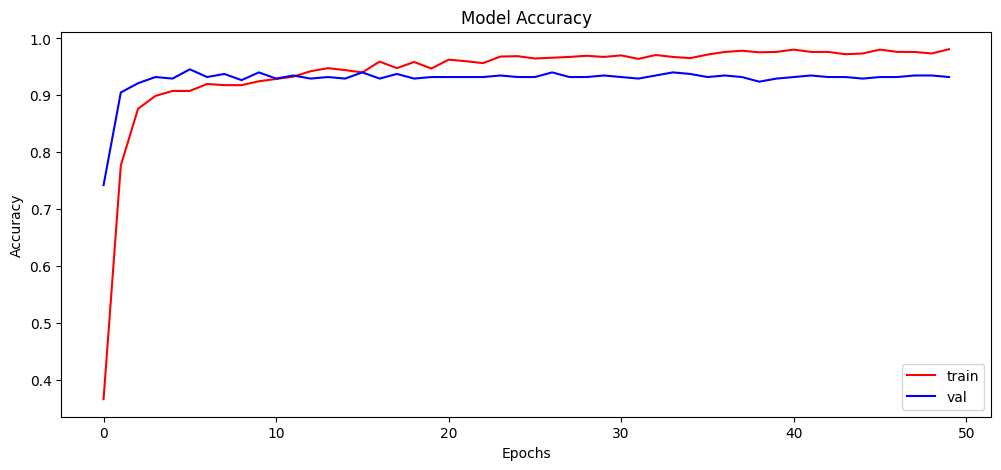

7/7 [==============================] - 2s 294ms/step - loss: 0.2573 - accuracy: 0.9268
Accuracy over the test set: 92.68 %


In [15]:
# Splitting the data set into training and testing data sets
X_train_and_val, X_test, Y_train_and_val, Y_test = train_test_split(X_data, Y_data, test_size=0.1, random_state=42)
# Splitting the training data set into training and validation data sets
X_train, X_val, Y_train, Y_val = train_test_split(X_train_and_val, Y_train_and_val, test_size=0.2, random_state=42)

# Training the model with data augmentation
from keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

epochs = 50
batch_size = 32

history = model.fit_generator(
    datagen.flow(X_train, Y_train, batch_size=batch_size),
    steps_per_epoch=len(X_train) / batch_size,
    epochs=epochs,
    validation_data=(X_val, Y_val)
)

# Plot the training history
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], color='r')
plt.plot(history.history['val_accuracy'], color='b')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'val'])
plt.show()

# Evaluate the model on the test set
score = model.evaluate(X_test, Y_test)
print('Accuracy over the test set:', round((score[1] * 100), 2), '%')

# Function to predict the breed of the dog from an image provided by the user
def predict_breed(user_image_path):
    img = image.load_img(user_image_path, target_size=(224, 224))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = img / 255.0

    pred = model.predict(img)
    breed = CLASS_NAME[np.argmax(pred)]
    return breed

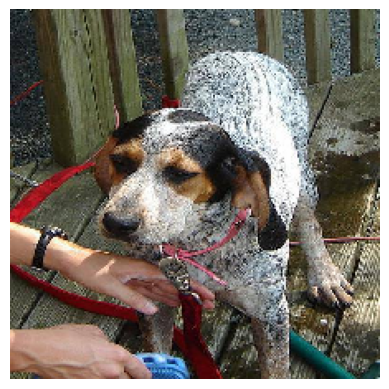

1/1 [==============================] - 1s 1s/step
Predicted breed:  bluetick


In [16]:
# Test the function with an image path
user_image_path = '/content/datasets/test/036da4b340288c17e5f7f60d2e09a530.jpg'
# Display an image from the test set using TensorFlow
def display_image(user_image_path):
    img = image.load_img(user_image_path, target_size=(224, 224))
    img = image.img_to_array(img)
    plt.imshow(img.astype(int))
    plt.axis('off')
    plt.show()
display_image(user_image_path)

print("Predicted breed: ", predict_breed(user_image_path))